# Experiments results for transfer learning

Here you will find plots and statistics related to experiments conducted for my thesis. The 2 deep learning model architectures examined are transformer and LSTM. The models were trained with these parameters:
- Transformer: 30 epochs with early stopping
- LSTM: 5 epochs with early stopping

## Loading the required python packages for processing

Loading global constant variables as well as useful functions

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import os

DATASET_NAMES = ("iotid20", "ustc-tfc-2016", "IoT-DS2", "CIC-UNSW-NB15", "mqtt-iot-ids2020", "ids-2018", "IoT-23")
DATASET_MAP = dict(zip(range(1, len(DATASET_NAMES) + 1), DATASET_NAMES))
RESULTS_DIR = "../results/reports"

def get_models_performance(transformer_csv, lstm_csv, metric="Accuracy"):
    transformer_df = pd.read_csv(transformer_csv)
    lstm_df = pd.read_csv(lstm_csv)
    normal_accuracy_per_dataset = pd.DataFrame()
    attack_accuracy_per_dataset = pd.DataFrame()
    for i, dataset_name in DATASET_MAP.items():
        trans_normals_accuracy = transformer_df.loc[(transformer_df["Class"] == 'Normal') & (transformer_df["Fold #"] == i)][metric].mean()
        trans_attack_accuracy = transformer_df.loc[(transformer_df["Class"] == 'Attack') & (transformer_df["Fold #"] == i)][metric].mean()
        lstm_normals_accuracy = lstm_df.loc[(lstm_df["Class"] == 'Normal') & (lstm_df["Fold #"] == i)][metric].mean()
        lstm_attack_accuracy = lstm_df.loc[(lstm_df["Class"] == 'Attack') & (lstm_df["Fold #"] == i)][metric].mean()
        normal_accuracy_per_dataset[dataset_name] = [trans_normals_accuracy, lstm_normals_accuracy]
        normal_accuracy_per_dataset["Model"] = ["Transformer", "LSTM"]
        attack_accuracy_per_dataset[dataset_name] = [trans_attack_accuracy, lstm_attack_accuracy]
        attack_accuracy_per_dataset["Model"] = ["Transformer", "LSTM"]

    attack_accuracy_per_dataset = attack_accuracy_per_dataset.set_index("Model")
    normal_accuracy_per_dataset = normal_accuracy_per_dataset.set_index("Model")
    return attack_accuracy_per_dataset, normal_accuracy_per_dataset

def get_binary_models_performance(transformer_csv, lstm_csv, metric="Accuracy"):
    transformer_df = pd.read_csv(transformer_csv)
    lstm_df = pd.read_csv(lstm_csv)
    accuracy_per_dataset = pd.DataFrame()
    for i, dataset_name in DATASET_MAP.items():
        trans_accuracy = transformer_df.loc[transformer_df["Fold #"] == i][metric].mean()
        lstm_accuracy = lstm_df.loc[lstm_df["Fold #"] == i][metric].mean()
        accuracy_per_dataset[dataset_name] = [trans_accuracy, lstm_accuracy]
        accuracy_per_dataset["Model"] = ["Transformer", "LSTM"]
    accuracy_per_dataset = accuracy_per_dataset.set_index("Model")
    return accuracy_per_dataset

## Transfer learning results

The experiments for transfer learning are;
1. Zero shot. One dataset is used for testing, the rest are used for training.
2. Few shot. Unlike zero shot, on training set a few samples are used from testing dataset. For our case, 1000 samples per class

Both experiments were run with the following configurations;
1. All features of datasets. Network specifif features included
2. Network specific features removed

### Zero shot tranfer learning

#### All network features included
Metrics per class:

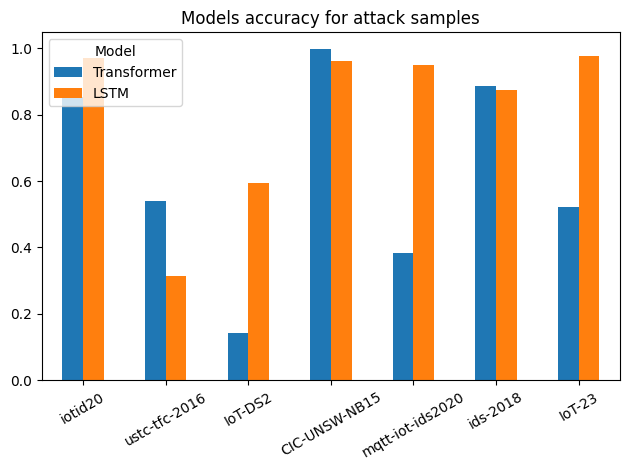

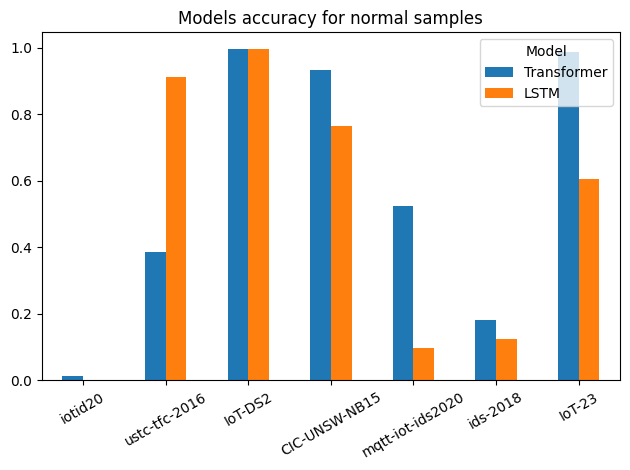

In [21]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/zero_shot/with_network_specific_features/30_epochs_early_stop/results_transformer_TL_zero_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/zero_shot/with_network_specific_features/5_epochs_early_stop/results_lstm_TL_zero_shot.csv")
attack_accuracy_per_dataset, normal_accuracy_per_dataset = get_models_performance(transformer_csv, lstm_csv)

ax = attack_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for attack samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("attack-accuracy.pdf")

ax = normal_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for normal samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("normal-accuracy.pdf")


Binary metrics:

Model,Transformer,LSTM
iotid20,0.442512,0.480277
ustc-tfc-2016,0.348997,0.681152
IoT-DS2,0.639258,0.785511
CIC-UNSW-NB15,0.265818,0.844173
mqtt-iot-ids2020,0.431983,0.495992
ids-2018,0.510612,0.538381
IoT-23,0.689743,0.941946


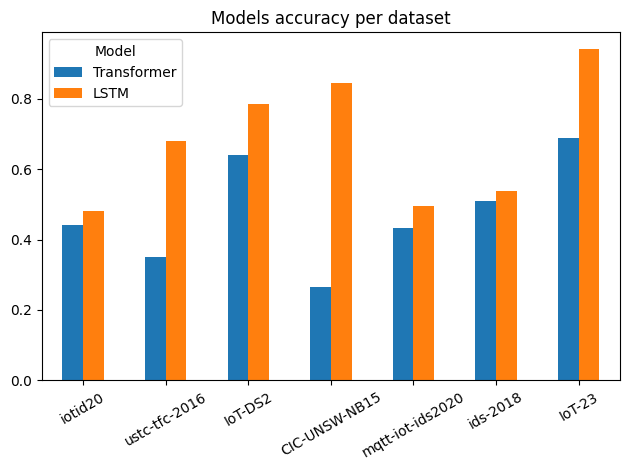

In [22]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/zero_shot/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_zero_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/zero_shot/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_zero_shot.csv")
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv)
precision_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, "Precision")
recall_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, "Recall")
f1_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, "F1 Score")

display(accuracy_per_dataset.T)
ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_zero_shot.pdf")


#### Network specific features removed

Binary metrics:

Model,Transformer,LSTM
iotid20,0.496847,0.487179
ustc-tfc-2016,0.756053,0.534966
IoT-DS2,0.796112,0.798052
CIC-UNSW-NB15,0.749771,0.619331
mqtt-iot-ids2020,0.560124,0.407492
ids-2018,0.618811,0.513950
IoT-23,0.504940,0.843218


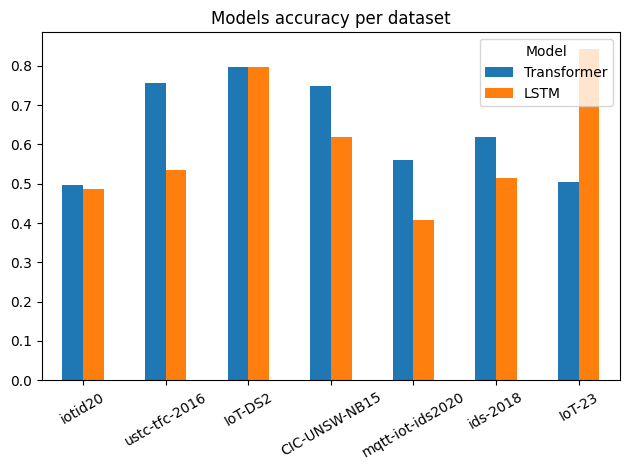

In [23]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/zero_shot/separate_removed_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_zero_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/zero_shot/separate_removed_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_zero_shot.csv")
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv)
precision_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, "Precision")
recall_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, "Recall")
f1_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, "F1 Score")

display(accuracy_per_dataset.T)
ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_removed_zero_shot.pdf")

### Few shot transfer learning
The following results are for 10000 samples per class infused from test set into the training set. Binary metrics only.
#### All network features included


Model,Transformer,LSTM
iotid20,0.668673,0.937343
ustc-tfc-2016,0.677672,0.991971
IoT-DS2,0.715088,0.974902
CIC-UNSW-NB15,0.361103,0.971167
mqtt-iot-ids2020,0.637590,0.966314
ids-2018,0.777650,0.933418
IoT-23,0.835684,0.997219


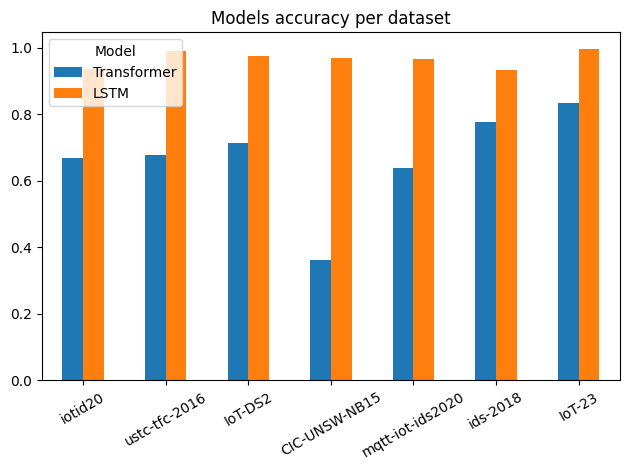

In [24]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/10000_samples/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_few_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/10000_samples/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_few_shot.csv")
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv)
precision_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, "Precision")
recall_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, "Recall")
f1_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, "F1 Score")

display(accuracy_per_dataset.T)
ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_few_shot_10000.pdf")

#### Without network-specific features
Binary metrics:

Model,Transformer,LSTM
iotid20,0.910047,0.924020
ustc-tfc-2016,0.973680,0.939363
IoT-DS2,0.968929,0.975298
CIC-UNSW-NB15,0.955383,0.893635
mqtt-iot-ids2020,0.962776,0.961404
ids-2018,0.912984,0.879786
IoT-23,0.991801,0.996096


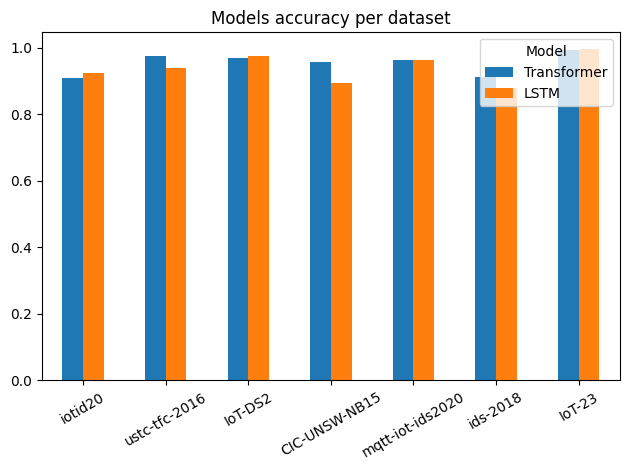

In [25]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/10000_samples/separate_removed_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_few_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/10000_samples/separate_removed_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_few_shot.csv")
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv)
precision_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, "Precision")
recall_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, "Recall")
f1_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, "F1 Score")

display(accuracy_per_dataset.T)
ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_removed_few_shot_10000.pdf")


The following results are for 1000 samples per class infused from test set into the training set.
#### All network features included

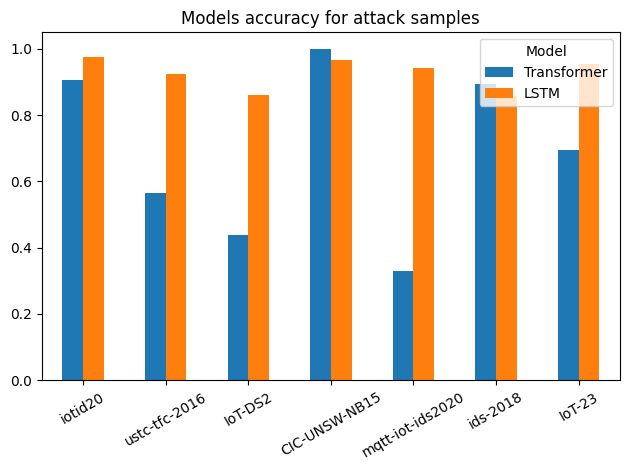

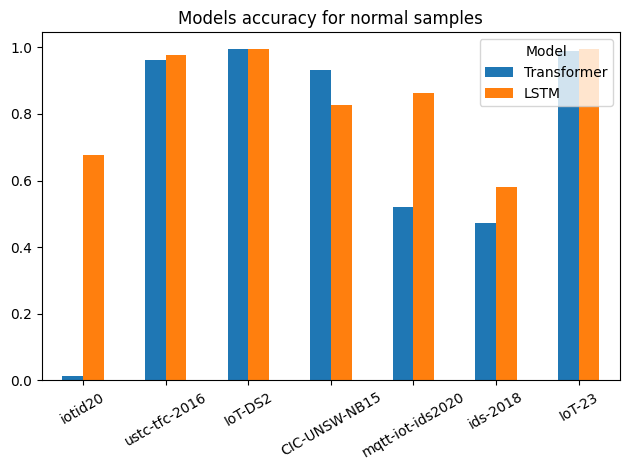

In [26]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/1000_samples/with_network_specific_features/30_epochs_early_stop/results_transformer_TL_few_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/1000_samples/with_network_specific_features/5_epochs_early_stop/results_lstm_TL_few_shot.csv")
attack_accuracy_per_dataset, normal_accuracy_per_dataset = get_models_performance(transformer_csv, lstm_csv)

ax = attack_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for attack samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("attack-accuracy.pdf")

ax = normal_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for normal samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("normal-accuracy.pdf")

Binary metrics:

Model,Transformer,LSTM
iotid20,0.462054,0.885160
ustc-tfc-2016,0.506843,0.957463
IoT-DS2,0.632233,0.927578
CIC-UNSW-NB15,0.372266,0.894476
mqtt-iot-ids2020,0.504972,0.911931
ids-2018,0.672895,0.749062
IoT-23,0.732489,0.994973


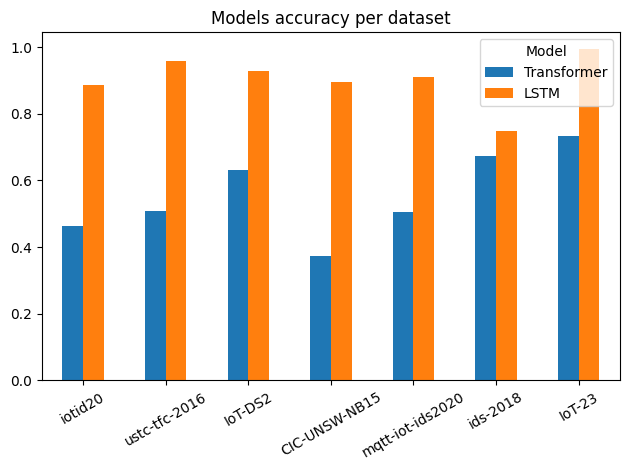

In [27]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/1000_samples/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_few_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/1000_samples/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_few_shot.csv")
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv)
precision_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, "Precision")
recall_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, "Recall")
f1_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, "F1 Score")

display(accuracy_per_dataset.T)
ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_few_shot_1000.pdf")

#### Without network-specific features

Binary metrics:

Model,Transformer,LSTM
iotid20,0.803866,0.768467
ustc-tfc-2016,0.913106,0.869748
IoT-DS2,0.920656,0.902392
CIC-UNSW-NB15,0.864119,0.804896
mqtt-iot-ids2020,0.942855,0.847047
ids-2018,0.819555,0.740825
IoT-23,0.991089,0.993615


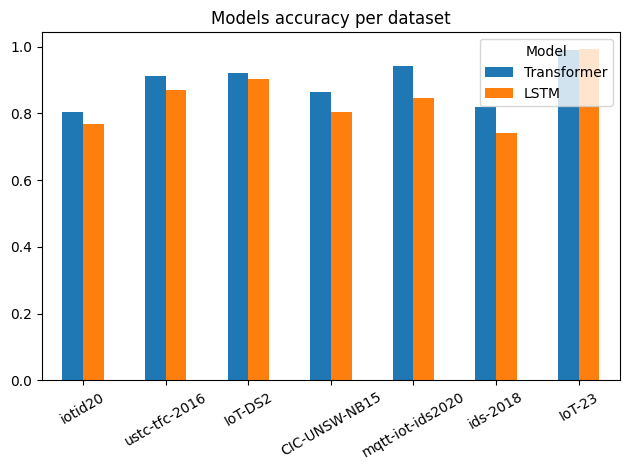

In [29]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/1000_samples/separate_removed_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_few_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/1000_samples/separate_removed_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_few_shot.csv")
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv)
precision_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, "Precision")
recall_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, "Recall")
f1_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv, "F1 Score")

display(accuracy_per_dataset.T)
ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_removed_few_shot_1000.pdf")

The following results are for 100 samples per class infused from test set into the training set.
#### With network specific features:

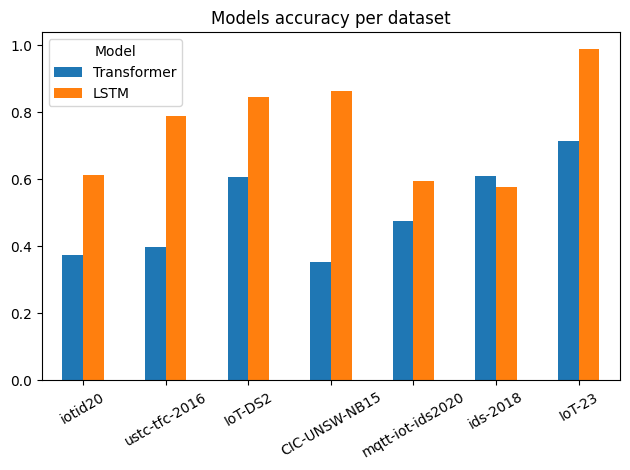

In [30]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/100_samples/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_few_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/100_samples/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_few_shot.csv")
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv)

ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_few_shot_100.pdf")

#### Without network specific features:


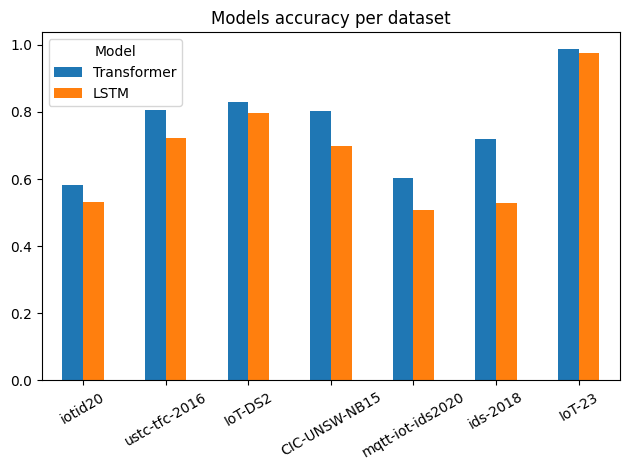

In [31]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/100_samples/separate_removed_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_few_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/100_samples/separate_removed_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_few_shot.csv")
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv)

ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_removed_few_shot_100.pdf")

The following results are for 10 samples per class infused from test set into training set
#### With network specific features

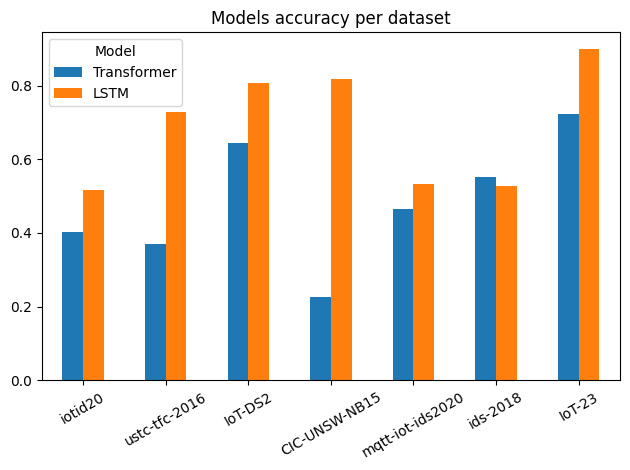

In [32]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/10_samples/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_few_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/10_samples/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_few_shot.csv")
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv)

ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_few_shot_10.pdf")

#### Without network specific features

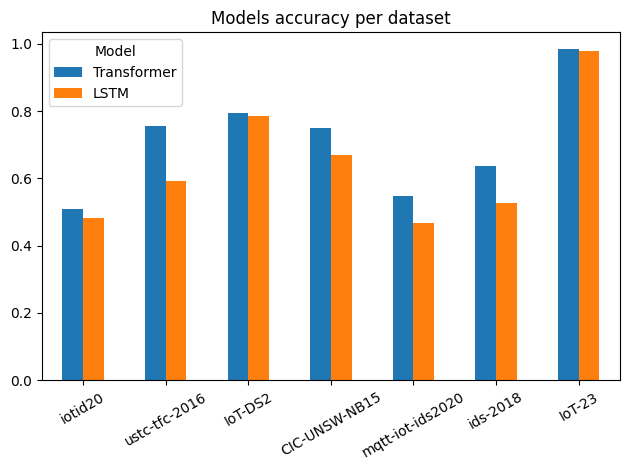

In [33]:
transformer_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/10_samples/separate_removed_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_few_shot.csv")
lstm_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/10_samples/separate_removed_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_few_shot.csv")
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv)

ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_removed_few_shot_10.pdf")

## Overall average performance per model
How infusion and network specific features affects overall model performance

### With network specific features

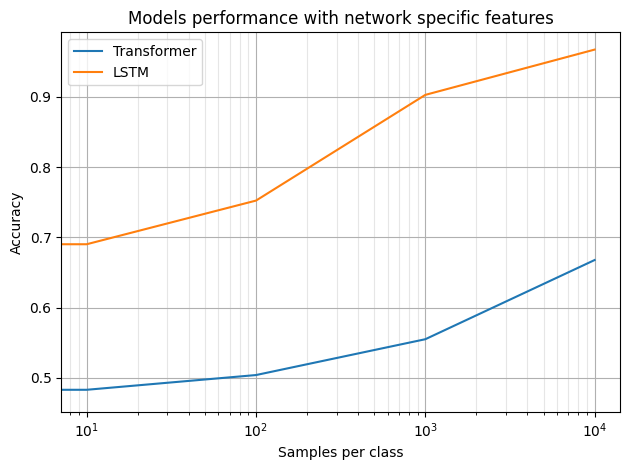

In [34]:
transformer_0_csv = os.path.join(RESULTS_DIR, "transformer/zero_shot/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_zero_shot.csv")
transformer_10_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/10_samples/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_few_shot.csv")
transformer_100_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/100_samples/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_few_shot.csv")
transformer_1000_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/1000_samples/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_few_shot.csv")
transformer_10000_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/10000_samples/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_few_shot.csv")

lstm_0_csv = os.path.join(RESULTS_DIR, "lstm/zero_shot/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_zero_shot.csv")
lstm_10_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/10_samples/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_few_shot.csv")
lstm_100_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/100_samples/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_few_shot.csv")
lstm_1000_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/1000_samples/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_few_shot.csv")
lstm_10000_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/10000_samples/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_few_shot.csv")

transformer_csvs = [transformer_0_csv, transformer_10_csv, transformer_100_csv, transformer_1000_csv, transformer_10000_csv]
lstm_csvs = [lstm_0_csv, lstm_10_csv, lstm_100_csv, lstm_1000_csv, lstm_10000_csv]
transformer_avg_accuracies = []
lstm_avg_accuracies = []

for i in range(len(transformer_csvs)):
    accuracy_per_model = get_binary_models_performance(transformer_csvs[i], lstm_csvs[i]).T
    transformer_avg_accuracies.append(accuracy_per_model["Transformer"].mean())
    lstm_avg_accuracies.append(accuracy_per_model["LSTM"].mean())

plt.plot([0, 10, 100, 1000, 10000], transformer_avg_accuracies, label="Transformer")
plt.plot([0, 10, 100, 1000, 10000], lstm_avg_accuracies, label="LSTM")
plt.semilogx()
plt.legend()
plt.grid()
plt.grid(which='minor', color="0.9")
plt.title("Models performance with network specific features")
plt.xlabel("Samples per class")
plt.ylabel("Accuracy")
plt.tight_layout(h_pad=3)
plt.savefig("model_performance_overall.pdf")


### Without network specific features


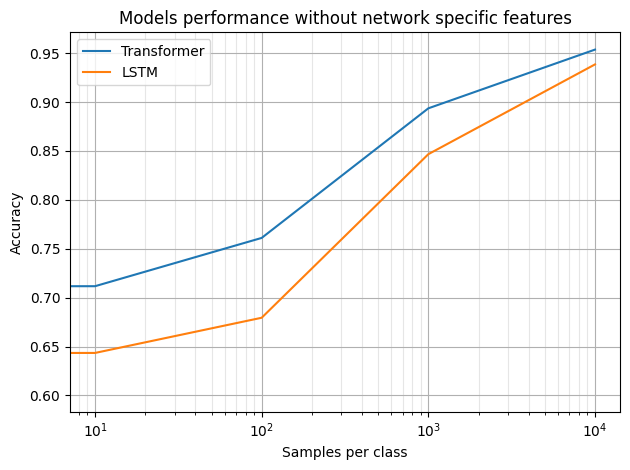

In [3]:
transformer_0_csv = os.path.join(RESULTS_DIR, "transformer/zero_shot/separate_removed_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_zero_shot.csv")
transformer_10_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/10_samples/separate_removed_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_few_shot.csv")
transformer_100_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/100_samples/separate_removed_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_few_shot.csv")
transformer_1000_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/1000_samples/separate_removed_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_few_shot.csv")
transformer_10000_csv = os.path.join(RESULTS_DIR, "transformer/few_shot/10000_samples/separate_removed_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_few_shot.csv")

lstm_0_csv = os.path.join(RESULTS_DIR, "lstm/zero_shot/separate_removed_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_zero_shot.csv")
lstm_10_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/10_samples/separate_removed_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_few_shot.csv")
lstm_100_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/100_samples/separate_removed_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_few_shot.csv")
lstm_1000_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/1000_samples/separate_removed_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_few_shot.csv")
lstm_10000_csv = os.path.join(RESULTS_DIR, "lstm/few_shot/10000_samples/separate_removed_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_few_shot.csv")

transformer_csvs = [transformer_0_csv, transformer_10_csv, transformer_100_csv, transformer_1000_csv, transformer_10000_csv]
lstm_csvs = [lstm_0_csv, lstm_10_csv, lstm_100_csv, lstm_1000_csv, lstm_10000_csv]
transformer_avg_accuracies = []
lstm_avg_accuracies = []

for i in range(len(transformer_csvs)):
    accuracy_per_model = get_binary_models_performance(transformer_csvs[i], lstm_csvs[i]).T
    transformer_avg_accuracies.append(accuracy_per_model["Transformer"].mean())
    lstm_avg_accuracies.append(accuracy_per_model["LSTM"].mean())

plt.plot([0, 10, 100, 1000, 10000], transformer_avg_accuracies, label="Transformer")
plt.plot([0, 10, 100, 1000, 10000], lstm_avg_accuracies, label="LSTM")
plt.semilogx()
plt.legend()
plt.grid()
plt.grid(which='minor', color="0.9")
plt.title("Models performance without network specific features")
plt.xlabel("Samples per class")
plt.ylabel("Accuracy")
plt.tight_layout(h_pad=3)
plt.savefig("model_performance_overall_removed.pdf")